# 02 — First Training Run

**Goal:** verify that the complete pipeline (environment + spiking actor-critic + R-STDP + backprop critic) can actually learn on a simple task.

**Task:** 5x5 gridworld, goal at (4,4), no obstacles, no noise. This is the simplest possible version — if the agent can't learn this, something is structurally broken.

**What we'll do:**

1. Baseline: random agent
2. Baseline: hand-coded greedy policy (upper bound for a naive non-learned policy)
3. Sanity check: confirm the untrained actor is producing spikes
4. Train the agent for 300 episodes
5. Plot learning curves (reward, steps-to-goal, success rate)
6. Plot diagnostics (spike counts, TD error, actor update magnitude)
7. Evaluate the trained agent vs. random
8. Interpretation

**Note:** This is a first-pass pipeline verification, not a final experiment. If learning works, we scale up to real experiments. If it fails, the diagnostics point to which module needs fixing.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spiking_rl.environment.gridworld import GridWorldEnv
from spiking_rl.learning.agent import AgentConfig, SpikingActorCriticAgent

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Torch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

d:\Research\reward-modulated-spiking-rl\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Torch: 2.14.0+cpu
CUDA: False


## 1. Baselines on the deterministic 5x5 gridworld

Before training anything, we establish what "doing nothing" and "following a hand-coded rule" look like. These are the reference points against which the trained agent will be judged.

In [2]:
# Fixed environment for all baselines and training. Same env config throughout.
def make_env() -> GridWorldEnv:
    return GridWorldEnv(
        size=5,
        start=(0, 0),
        goal=(4, 4),
        max_steps=100,
        render_mode=None,
    )

env = make_env()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box(0.0, 1.0, (4,), float32)
Action space: Discrete(4)


In [3]:
def random_policy_episode(env, seed):
    """Run a random policy for one episode and return metrics."""
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated = False
    truncated = False
    for _ in range(100):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    return {
        "total_reward": total_reward,
        "steps": steps,
        "success": bool(terminated and not truncated),
    }


def greedy_policy_episode(env, seed):
    """Hand-coded greedy policy: move toward goal (down first, then right)."""
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated = False
    truncated = False
    for _ in range(100):
        pos = env._agent_pos
        goal = env.goal
        dr = goal[0] - pos[0]
        dc = goal[1] - pos[1]
        if dr > 0:
            action = 2  # down
        elif dc > 0:
            action = 1  # right
        else:
            action = 0
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    return {
        "total_reward": total_reward,
        "steps": steps,
        "success": bool(terminated and not truncated),
    }


N_EVAL = 50
random_results = [random_policy_episode(env, seed=i) for i in range(N_EVAL)]
greedy_results = [greedy_policy_episode(env, seed=1000 + i) for i in range(N_EVAL)]

random_summary = {
    "mean_reward": np.mean([r["total_reward"] for r in random_results]),
    "success_rate": np.mean([r["success"] for r in random_results]),
    "mean_steps": np.mean([r["steps"] for r in random_results]),
}
greedy_summary = {
    "mean_reward": np.mean([r["total_reward"] for r in greedy_results]),
    "success_rate": np.mean([r["success"] for r in greedy_results]),
    "mean_steps": np.mean([r["steps"] for r in greedy_results]),
}

print(f"{'Policy':<20s} {'mean reward':>12s} {'success rate':>14s} {'mean steps':>12s}")
print("-" * 62)
print(f"{'random':<20s} {random_summary['mean_reward']:>12.3f} "
      f"{random_summary['success_rate']:>14.3f} {random_summary['mean_steps']:>12.1f}")
print(f"{'hand-coded greedy':<20s} {greedy_summary['mean_reward']:>12.3f} "
      f"{greedy_summary['success_rate']:>14.3f} {greedy_summary['mean_steps']:>12.1f}")

Policy                mean reward   success rate   mean steps
--------------------------------------------------------------
random                      0.520          0.520         72.2
hand-coded greedy           1.000          1.000          8.0


## 2. Sanity check: is the untrained actor firing?

Before spending time on training, we verify the actor is producing spikes. If it isn't, R-STDP can't update the output layer and training will produce no learning. This catches the dying-signal class of bugs immediately.

In [4]:
config = AgentConfig(
    actor_hidden=(64, 64),
    critic_hidden=(64, 64),
    decision_steps=5,
    actor_lr=1e-3,
    critic_lr=1e-3,
    third_factor="td_error",
    log_every=25,
)

torch.manual_seed(SEED)
env = make_env()
agent = SpikingActorCriticAgent(env, config)

# Drive the actor with a batch of observations and count output spikes.
obs, _ = env.reset(seed=0)
obs_t = agent._to_tensor(obs)
agent.ac.reset()

spike_counts_over_time = []
for step in range(20):
    _, _, spike_counts = agent.ac.sample_action(obs_t)
    spike_counts_over_time.append(spike_counts.sum().item())

print("Actor output-layer spike counts over 20 forward passes:")
print(spike_counts_over_time)
print(f"Total spikes: {sum(spike_counts_over_time):.0f}")
print()
if sum(spike_counts_over_time) == 0:
    raise RuntimeError("Actor output layer is not firing. Training will not learn.")
else:
    print("✓ Actor is firing.")

Actor output-layer spike counts over 20 forward passes:
[3.0, 4.0, 3.0, 4.0, 4.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 4.0, 3.0, 4.0, 4.0, 4.0, 3.0, 4.0]
Total spikes: 74

✓ Actor is firing.


## 3. First training run

300 episodes on the deterministic gridworld. Each episode uses a different seed so the initial position varies slightly (though here the start is fixed, so seeds mainly affect any internal randomness).

In [5]:
# Diagnostic: does the actor's output depend on the observation?

# Run the untrained actor on a batch of diverse observations and check
# whether the output spike counts vary across them.
env_diag = GridWorldEnv(size=5, goal=(4, 4), max_steps=100, render_mode=None)

# Collect a batch of diverse observations by walking randomly.
observations = []
for seed in range(64):
    obs, _ = env_diag.reset(seed=seed)
    observations.append(obs)
    for _ in range(5):
        action = env_diag.action_space.sample()
        obs, _, term, trunc, _ = env_diag.step(action)
        observations.append(obs)
        if term or trunc:
            break

obs_batch = torch.tensor(np.array(observations[:64]), dtype=torch.float32)

torch.manual_seed(SEED)
env_diag = make_env()
agent_diag = SpikingActorCriticAgent(env_diag, config)
agent_diag.ac.reset()

with torch.no_grad():
    spike_counts, _ = agent_diag.ac.actor(obs_batch, steps=5)

# Spike counts: shape (64, 4)
print("Spike counts across 64 observations:")
print(f"  shape: {spike_counts.shape}")
print(f"  min:   {spike_counts.min().item():.3f}")
print(f"  max:   {spike_counts.max().item():.3f}")
print(f"  mean:  {spike_counts.mean().item():.3f}")
print(f"  std:   {spike_counts.std().item():.3f}")
print()
print(f"Per-action std (how much each action varies across obs):")
for a in range(4):
    print(f"  action {a}: std = {spike_counts[:, a].std().item():.4f}")

# If the standard deviation is near zero, the actor is state-invariant.
# If it's substantial, the actor IS conditioning on the observation.
overall_std = spike_counts.std().item()
if overall_std < 0.1:
    print("\n⚠️  WARNING: Actor output is nearly constant across observations.")
    print("   The actor is not conditioning on the input. Reward shaping")
    print("   alone will not fix this. Consider increasing `tau`.")
else:
    print(f"\n✓ Actor output varies across observations (std = {overall_std:.3f}).")
    print("  The actor can condition on state. Reward shaping should help.")

Spike counts across 64 observations:
  shape: torch.Size([64, 4])
  min:   0.000
  max:   3.000
  mean:  0.695
  std:   0.855

Per-action std (how much each action varies across obs):
  action 0: std = 0.0000
  action 1: std = 0.0000
  action 2: std = 0.1250
  action 3: std = 0.4270

✓ Actor output varies across observations (std = 0.855).
  The actor can condition on state. Reward shaping should help.


In [6]:
config = AgentConfig(
    actor_hidden=(64, 64),
    critic_hidden=(64, 64),
    decision_steps=5,
    actor_lr=1e-3,
    critic_lr=1e-3,
    third_factor="td_error",
    log_every=25,
)

def make_env() -> GridWorldEnv:
    return GridWorldEnv(
        size=5,
        start=(0, 0),
        goal=(4, 4),
        max_steps=100,
        step_reward=-0.01,   # reward shaping: dense signal; every step costs a tiny bit
        render_mode=None,
    )

N_EPISODES = 300

torch.manual_seed(SEED)
env = make_env()
agent = SpikingActorCriticAgent(env, config)

history = agent.train(n_episodes=N_EPISODES, seed_start=0, verbose=True)

Episode    25/300 | reward=-0.103 | spikes=   4.262 | td_err=+0.0326 | act_upd=0.4076 | div=1.1 | baseline=+0.000
Episode    50/300 | reward=-0.052 | spikes=   0.000 | td_err=+0.0165 | act_upd=0.0010 | div=1.0 | baseline=+0.000
Episode    75/300 | reward=-0.315 | spikes=   0.000 | td_err=+0.0143 | act_upd=0.0000 | div=1.0 | baseline=+0.000
Episode   100/300 | reward=+0.182 | spikes=   0.000 | td_err=+0.0295 | act_upd=0.0000 | div=1.0 | baseline=+0.000
Episode   125/300 | reward=+0.037 | spikes=   0.000 | td_err=+0.0292 | act_upd=0.0000 | div=1.0 | baseline=+0.000
Episode   150/300 | reward=-0.305 | spikes=   0.000 | td_err=+0.0141 | act_upd=0.0000 | div=1.0 | baseline=+0.000
Episode   175/300 | reward=-0.105 | spikes=   0.000 | td_err=+0.0195 | act_upd=0.0000 | div=1.0 | baseline=+0.000
Episode   200/300 | reward=-0.220 | spikes=   0.000 | td_err=+0.0254 | act_upd=0.0000 | div=1.0 | baseline=+0.000
Episode   225/300 | reward=-0.075 | spikes=   0.000 | td_err=+0.0193 | act_upd=0.0000 | 

## 4. Learning curves

Plot the raw episode-by-episode metrics and a smoothed trend line.

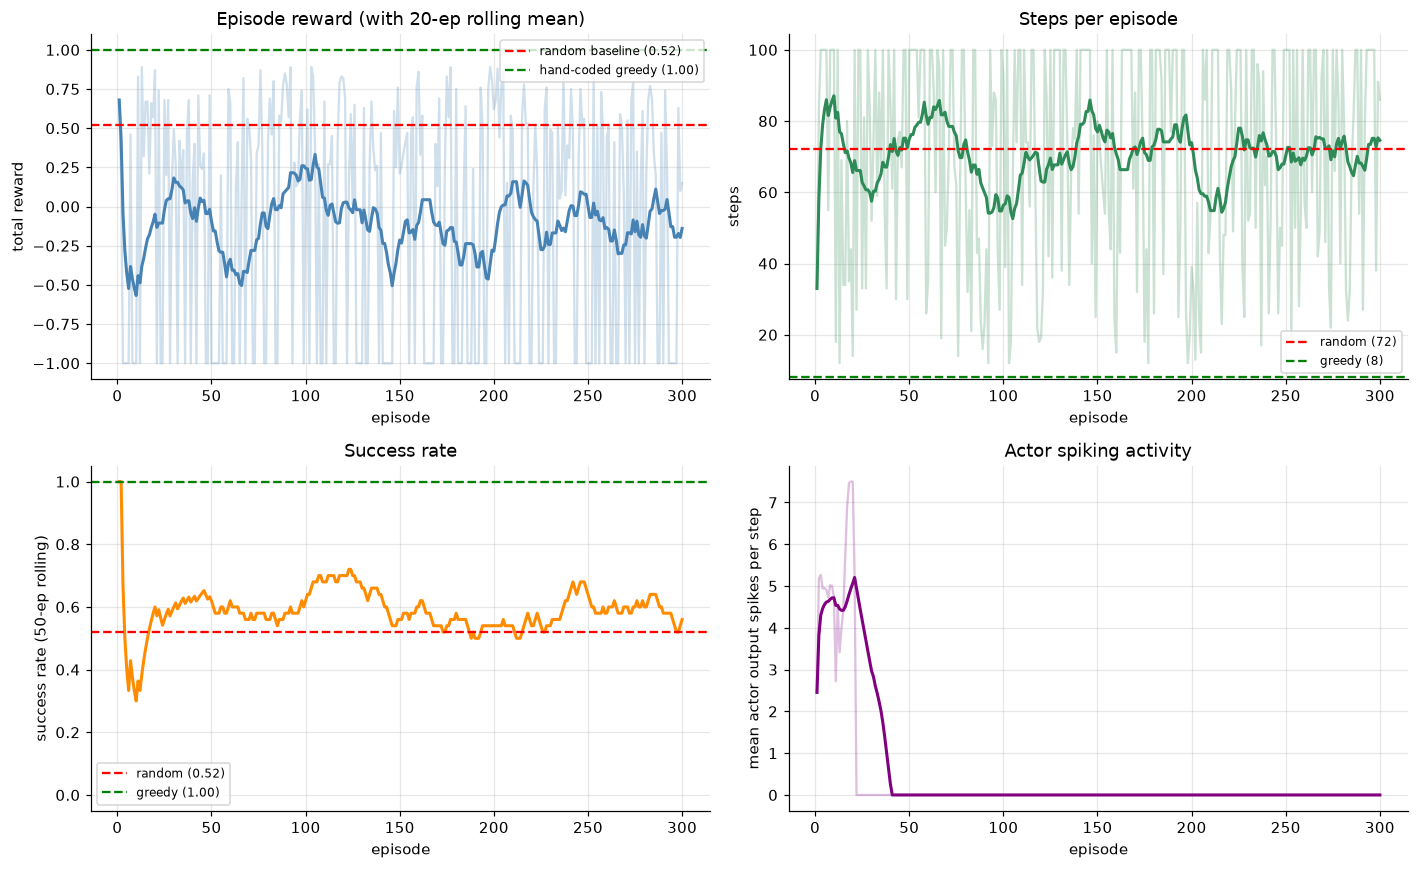

In [7]:
df = pd.DataFrame(history)


def smooth(x, window=20):
    return pd.Series(x).rolling(window=window, min_periods=1).mean().to_numpy()


fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Panel 1: episode reward ---
ax = axes[0, 0]
ax.plot(df["episode"], df["total_reward"], alpha=0.25, color="steelblue")
ax.plot(df["episode"], smooth(df["total_reward"]), color="steelblue", linewidth=2)
ax.axhline(random_summary["mean_reward"], color="red", linestyle="--",
           label=f"random baseline ({random_summary['mean_reward']:.2f})")
ax.axhline(greedy_summary["mean_reward"], color="green", linestyle="--",
           label=f"hand-coded greedy ({greedy_summary['mean_reward']:.2f})")
ax.set_xlabel("episode")
ax.set_ylabel("total reward")
ax.set_title("Episode reward (with 20-ep rolling mean)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 2: steps per episode ---
ax = axes[0, 1]
ax.plot(df["episode"], df["steps"], alpha=0.25, color="seagreen")
ax.plot(df["episode"], smooth(df["steps"]), color="seagreen", linewidth=2)
ax.axhline(random_summary["mean_steps"], color="red", linestyle="--",
           label=f"random ({random_summary['mean_steps']:.0f})")
ax.axhline(greedy_summary["mean_steps"], color="green", linestyle="--",
           label=f"greedy ({greedy_summary['mean_steps']:.0f})")
ax.set_xlabel("episode")
ax.set_ylabel("steps")
ax.set_title("Steps per episode")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 3: success over rolling window ---
ax = axes[1, 0]
success_rolling = smooth(df["success"].astype(float), window=50)
ax.plot(df["episode"], success_rolling, color="darkorange", linewidth=2)
ax.axhline(random_summary["success_rate"], color="red", linestyle="--",
           label=f"random ({random_summary['success_rate']:.2f})")
ax.axhline(greedy_summary["success_rate"], color="green", linestyle="--",
           label=f"greedy ({greedy_summary['success_rate']:.2f})")
ax.set_xlabel("episode")
ax.set_ylabel("success rate (50-ep rolling)")
ax.set_title("Success rate")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 4: actor spikes per episode ---
ax = axes[1, 1]
ax.plot(df["episode"], df["mean_actor_spikes"], alpha=0.25, color="purple")
ax.plot(df["episode"], smooth(df["mean_actor_spikes"]), color="purple", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("mean actor output spikes per step")
ax.set_title("Actor spiking activity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "first_training_run.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Diagnostic traces

The learning curves show whether performance improves. These diagnostics show *why* — or why not.

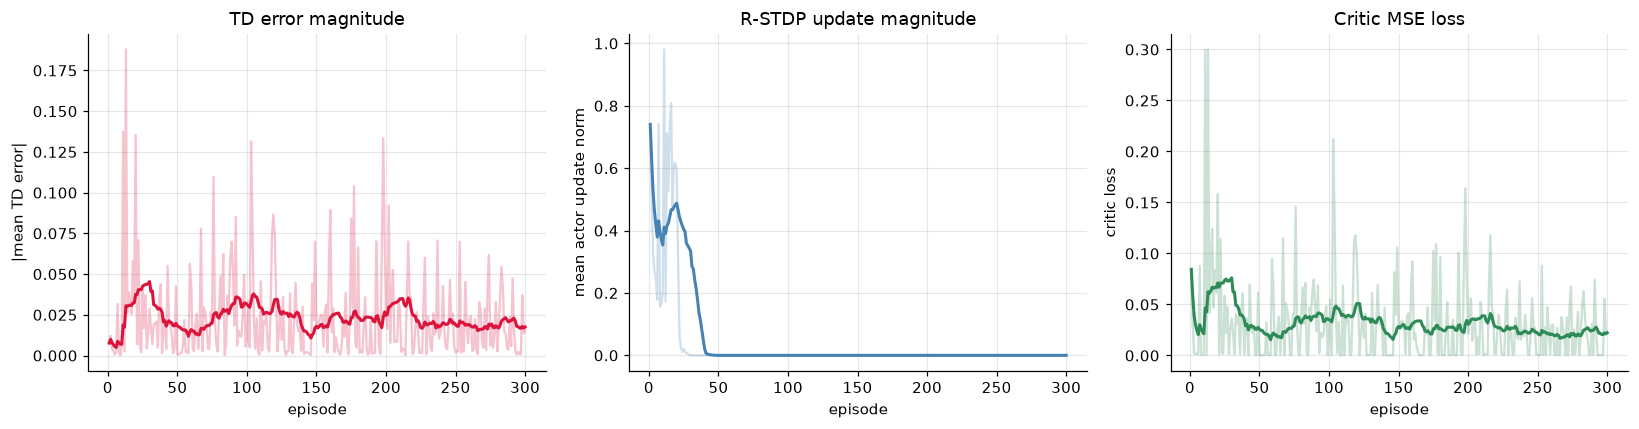

Diagnostic summary (last 50 episodes):
  mean reward:         -0.171
  success rate:        0.560
  mean actor spikes:   0.000
  mean |td error|:     0.0178
  mean actor update:   0.00000
  mean critic loss:    0.0212
  reward baseline:     +0.000


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- TD error magnitude ---
ax = axes[0]
ax.plot(df["episode"], np.abs(df["mean_td_error"]), alpha=0.25, color="crimson")
ax.plot(df["episode"], smooth(np.abs(df["mean_td_error"])),
        color="crimson", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("|mean TD error|")
ax.set_title("TD error magnitude")
ax.grid(alpha=0.3)

# --- Actor update magnitude ---
ax = axes[1]
ax.plot(df["episode"], df["mean_actor_update"], alpha=0.25, color="steelblue")
ax.plot(df["episode"], smooth(df["mean_actor_update"]),
        color="steelblue", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("mean actor update norm")
ax.set_title("R-STDP update magnitude")
ax.grid(alpha=0.3)

# --- Critic loss ---
ax = axes[2]
ax.plot(df["episode"], df["mean_critic_loss"], alpha=0.25, color="seagreen")
ax.plot(df["episode"], smooth(df["mean_critic_loss"]),
        color="seagreen", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("critic loss")
ax.set_title("Critic MSE loss")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics.
print("Diagnostic summary (last 50 episodes):")
tail = df.tail(50)
print(f"  mean reward:         {tail['total_reward'].mean():+.3f}")
print(f"  success rate:        {tail['success'].mean():.3f}")
print(f"  mean actor spikes:   {tail['mean_actor_spikes'].mean():.3f}")
print(f"  mean |td error|:     {tail['mean_td_error'].abs().mean():.4f}")
print(f"  mean actor update:   {tail['mean_actor_update'].mean():.5f}")
print(f"  mean critic loss:    {tail['mean_critic_loss'].mean():.4f}")
print(f"  reward baseline:     {tail['baseline'].iloc[-1]:+.3f}")

## 6. Evaluation vs. baselines

Run 100 evaluation episodes with the trained actor (greedy action selection, no learning, no noise).

In [9]:
trained_eval = agent.evaluate(n_episodes=100, seed_start=10_000, greedy=True)

print(f"{'Policy':<20s} {'mean reward':>12s} {'success rate':>14s} {'mean steps':>12s}")
print("-" * 62)
print(f"{'random':<20s} {random_summary['mean_reward']:>12.3f} "
      f"{random_summary['success_rate']:>14.3f} {random_summary['mean_steps']:>12.1f}")
print(f"{'hand-coded greedy':<20s} {greedy_summary['mean_reward']:>12.3f} "
      f"{greedy_summary['success_rate']:>14.3f} {greedy_summary['mean_steps']:>12.1f}")
print(f"{'trained agent':<20s} {trained_eval['mean_reward']:>12.3f} "
      f"{trained_eval['success_rate']:>14.3f} {trained_eval['mean_steps']:>12.1f}")

Policy                mean reward   success rate   mean steps
--------------------------------------------------------------
random                      0.520          0.520         72.2
hand-coded greedy           1.000          1.000          8.0
trained agent              -1.000          0.000        100.0


In [10]:
# Cell A: Does greedy action vary across states?
env_diag = make_env()
env_diag.reset(seed=0)
observations = []
for _ in range(500):
    action = env_diag.action_space.sample()
    obs, _, term, trunc, _ = env_diag.step(action)
    observations.append(obs)
    if term or trunc:
        env_diag.reset(seed=0)
observations = observations[:128]
obs_batch = torch.tensor(np.array(observations), dtype=torch.float32)

torch.manual_seed(SEED)
agent_for_diag = SpikingActorCriticAgent(make_env(), config)
agent_for_diag.ac.load_state_dict(agent.ac.state_dict())  # use trained weights

with torch.no_grad():
    spike_counts, _ = agent_for_diag.ac.actor(obs_batch, steps=5)
    greedy_actions = spike_counts.argmax(dim=-1)

unique, counts = greedy_actions.unique(return_counts=True)
print("Greedy action distribution across 128 random observations:")
for u, c in zip(unique.tolist(), counts.tolist()):
    print(f"  action {u}: {c} times ({100*c/len(greedy_actions):.1f}%)")
print(f"\nUnique greedy actions: {unique.tolist()}")

Greedy action distribution across 128 random observations:
  action 0: 128 times (100.0%)

Unique greedy actions: [0]


In [11]:
# Cell B: Compare greedy vs sampling evaluation
greedy_eval = agent.evaluate(n_episodes=50, greedy=True)
sampled_eval = agent.evaluate(n_episodes=50, greedy=False)

print(f"Greedy eval:  reward={greedy_eval['mean_reward']:+.3f}  "
      f"success={greedy_eval['success_rate']:.3f}  steps={greedy_eval['mean_steps']:.1f}")
print(f"Sampled eval: reward={sampled_eval['mean_reward']:+.3f}  "
      f"success={sampled_eval['success_rate']:.3f}  steps={sampled_eval['mean_steps']:.1f}")

Greedy eval:  reward=-1.000  success=0.000  steps=100.0
Sampled eval: reward=-0.037  success=0.660  steps=70.4


In [12]:
# Cell C: How spread are the spike counts?
with torch.no_grad():
    spike_counts, _ = agent_for_diag.ac.actor(obs_batch, steps=5)
    sorted_counts, _ = spike_counts.sort(dim=-1, descending=True)
    margin = sorted_counts[:, 0] - sorted_counts[:, 1]
    print(f"Top-vs-second spike count margin across obs:")
    print(f"  mean: {margin.mean().item():.4f}")
    print(f"  std:  {margin.std().item():.4f}")
    print(f"  min:  {margin.min().item():.4f}")
    print(f"  max:  {margin.max().item():.4f}")
    print(f"  fraction with margin < 0.1: {(margin < 0.1).float().mean().item():.3f}")

Top-vs-second spike count margin across obs:
  mean: 0.0000
  std:  0.0000
  min:  0.0000
  max:  0.0000
  fraction with margin < 0.1: 1.000


## 7. Interpretation

Fill in the blanks based on what you saw in the plots above.

### If the trained agent beats random but not greedy:
**Expected.** 300 episodes is short and the network has to discover the goal from scratch. The result "learns faster than random" is exactly what we want to see at this stage. We extend training and add noise in later experiments.

### If the trained agent matches or beats greedy:
**Very good.** The spiking actor has learned the optimal policy. Note that greedy is optimal on the deterministic 5x5 grid, so the ceiling is `1.0` success rate. If we're close, the pipeline works.

### If the trained agent does not beat random:
**Structural problem.** Check the diagnostic plots:

- If `mean actor spikes` is ~0 → the actor is not firing, no eligibility, no learning. Revisit the SNN init or the threshold.
- If `mean actor update` is ~0 → the modulation signal is zero. Check TD error.
- If `mean |td error|` decreases but reward doesn't improve → the critic is learning but the actor is not.
- If critic loss explodes → gradient issue. Reduce `critic_lr` or increase gradient clipping.

In [ ]:
# Save the history for later reference.
history_path = REPO_ROOT / "results" / "metrics" / "first_training_run.csv"
df.to_csv(history_path, index=False)
print(f"Saved history to: {history_path}")